<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/rnn_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN vs LSTM on Jena Climate Dataset

This dataset has real temporal dependencies → LSTM advantage becomes visible.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
import kagglehub
path = kagglehub.dataset_download("stytch16/jena-climate-2009-2016")

print("Downloaded to:", path)

Using Colab cache for faster access to the 'jena-climate-2009-2016' dataset.
Downloaded to: /kaggle/input/jena-climate-2009-2016


In [ ]:
!ls /root/.cache/kagglehub/datasets/stytch16/jena-climate-2009-2016/versions/1

jena_climate_2009_2016.csv


In [ ]:
import os
import shutil

src = "/root/.cache/kagglehub/datasets/stytch16/jena-climate-2009-2016/versions/1/jena_climate_2009_2016.csv"
dst = "/content/jena_climate_2009_2016.csv"

shutil.copy(src, dst)

print("Copied to:", dst)

Copied to: /content/jena_climate_2009_2016.csv


In [ ]:
!ls

jena_climate_2009_2016.csv  sample_data


In [ ]:
# Load dataset (download from Kaggle: jena_climate_2009_2016.csv)
df = pd.read_csv('jena_climate_2009_2016.csv')

# Use temperature + other features
features = ['T (degC)', 'p (mbar)', 'rho (g/m**3)', 'wv (m/s)']
df = df[features]

data = df.values

# Scale
scaler = MinMaxScaler((-1,1))
data = scaler.fit_transform(data)

In [ ]:
# Create sequences
def create_data(data, step=72):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step, 0])  # predict temperature
    return np.array(X), np.array(y)

X, y = create_data(data)

In [ ]:
# Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# RNN
rnn = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    SimpleRNN(64, return_sequences=True),
    SimpleRNN(64),
    Dense(1)
])

rnn.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
rnn.fit(X_train, y_train, epochs=20, batch_size=64, verbose=1)

Epoch 1/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 118s 22ms/step - loss: 2.8630e-04
Epoch 2/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 144s 22ms/step - loss: 8.4106e-05
Epoch 3/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 134s 21ms/step - loss: 7.1122e-05
Epoch 4/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 110s 21ms/step - loss: 6.4833e-05
Epoch 5/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 112s 21ms/step - loss: 6.2361e-05
Epoch 6/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 142s 21ms/step - loss: 5.9469e-05
Epoch 7/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 111s 21ms/step - loss: 5.7553e-05
Epoch 8/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 112s 21ms/step - loss: 5.6315e-05
Epoch 9/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 144s 22ms/step - loss: 6.6777e-05
Epoch 10/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 113s 22ms/step - loss: 5.4535e-05
Epoch 11/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 113s 21ms/step - loss: 5.4548e-05
Epoch 12/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 142s 21ms/step - loss: 6.8292e-04
Epoch 13/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 154s 24ms/step - loss: 1.0168e-04
Epoch 14

In [ ]:
# LSTM
lstm = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(64),
    Dense(1)
])

lstm.compile(optimizer=tf.keras.optimizers.Adam(0.0005), loss='mse')
lstm.fit(X_train, y_train, epochs=20, batch_size=64, verbose=1)

Epoch 1/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 349s 66ms/step - loss: 3.0713e-04
Epoch 2/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 364s 63ms/step - loss: 5.4747e-05
Epoch 3/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 363s 59ms/step - loss: 5.1367e-05
Epoch 4/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 349s 64ms/step - loss: 4.9285e-05
Epoch 5/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 325s 62ms/step - loss: 4.8084e-05
Epoch 6/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 310s 59ms/step - loss: 4.7324e-05
Epoch 7/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 324s 62ms/step - loss: 4.6820e-05
Epoch 8/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 378s 61ms/step - loss: 4.6446e-05
Epoch 9/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 314s 60ms/step - loss: 4.6145e-05
Epoch 10/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 324s 60ms/step - loss: 4.5902e-05
Epoch 11/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 318s 59ms/step - loss: 4.5701e-05
Epoch 12/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 320s 61ms/step - loss: 4.5530e-05
Epoch 13/20
5256/5256 ━━━━━━━━━━━━━━━━━━━━ 314s 60ms/step - loss: 4.5386e-05
Epoch 14

In [ ]:
# Predictions
rnn_pred = rnn.predict(X_test)
lstm_pred = lstm.predict(X_test)

# Only inverse scale temperature
y_test_rescaled = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), data.shape[1]-1))], axis=1)
)[:,0]

rnn_rescaled = scaler.inverse_transform(
    np.concatenate([rnn_pred, np.zeros((len(rnn_pred), data.shape[1]-1))], axis=1)
)[:,0]

lstm_rescaled = scaler.inverse_transform(
    np.concatenate([lstm_pred, np.zeros((len(lstm_pred), data.shape[1]-1))], axis=1)
)[:,0]

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step


In [ ]:
# RMSE
from sklearn.metrics import mean_squared_error

rnn_rmse = np.sqrt(mean_squared_error(y_test_rescaled, rnn_rescaled))
lstm_rmse = np.sqrt(mean_squared_error(y_test_rescaled, lstm_rescaled))

print('RNN RMSE:', rnn_rmse)
print('LSTM RMSE:', lstm_rmse)

RNN RMSE: 0.32601006738913035
LSTM RMSE: 0.21193284194543557


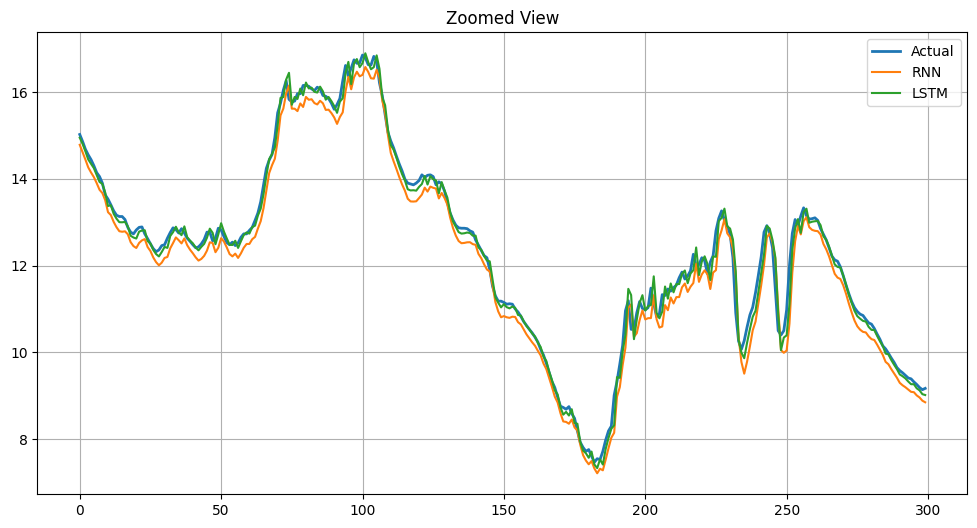

In [ ]:
start = 0
end = 300

plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled[start:end], label='Actual', linewidth=2)
plt.plot(rnn_rescaled[start:end], label='RNN')
plt.plot(lstm_rescaled[start:end], label='LSTM')

plt.title('Zoomed View')
plt.legend()
plt.grid(True)
plt.show()